
# TRNG Approach A - RTC vs TCC Jitter on XMEGA (CW303)
Quick testbench to compile, flash, collect, and evaluate random bits from a
TRUERA-style TRNG adapted to the ATxmega128D4 on ChipWhisperer CW303.

> Duplicate this notebook to create Approach B/C/D (e.g., ADC noise, ring oscillators, SRAM startup), changing only the acquisition cell title & acquisition code. Each notebook keeps the same test battery, so you can compare results apples-to-apples.



## Requirements
- ChipWhisperer installed (`pip install chipwhisperer`), hardware connected (CW-Lite/NAE-Scope + CW303 XMEGA target).
- Your TRNG firmware placed in `FW_DIR` (below) and builds with `make PLATFORM=CW303` to create `.hex`.
- The firmware implements SimpleSerial command: `r<N>` -> returns `ceil(N/8)` bytes (MSB-first packing).

If you use my minimal no-FIFO firmware from chat, you're good.


## 1) Build firmware

In [1]:
import chipwhisperer as cw
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import trange

scope = cw.scope()
target = cw.target(scope, cw.targets.SimpleSerial2)
scope.default_setup()

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 11224688                  to 33653700                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 0                         to 30050216                 
scope.clock.adc_rate                     changed from 0.0                       to 30050216.0               
scope.clock.clkgen_

In [2]:
%%bash
make PLATFORM=CWLITEXMEGA SOURCE=osc_trng.c  SS_VER=SS_VER_2_1

No CRYPTO_TARGET passed - defaulting to TINYAES128C
Building for platform CWLITEXMEGA with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_2_1
SS_VER set to SS_VER_2_1
Blank crypto options, building for AES128
.
Welcome to another exciting ChipWhisperer target build!!
avr-gcc (GCC) 7.3.0
Copyright (C) 2017 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CWLITEXMEGA 
.
Compiling:
-en     osc_trng.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/simpleserial/simpleserial.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal/hal.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal//xmega/XMEGA_AES_driver.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal//xmega/uart.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal//xmega/usart_driver.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/h

## 2) Program target (XMEGA on CW303)

In [3]:
hex = "output-CWLITEXMEGA.hex"
cw.program_target(scope, cw.programmers.XMEGAProgrammer, hex)

XMEGA Programming flash...
XMEGA Reading flash...
Verified flash OK, 4557 bytes


## 3) Acquire random bits - Approach A: RTC vs TCC jitter

In [7]:
import numpy as np
import time
import logging   # <-- add this

# Silence ChipWhisperer "Target" warnings
logging.getLogger("ChipWhisperer Target").setLevel(logging.ERROR)

# CHUNK = 10           # safe per-request size
# I = 10
# N = I*CHUNK               # total bytes you want
# buf = bytearray()

# # Loop until we have N bytes
# remaining = N
# while remaining > 0:
#     target.flush()
#     want = min(CHUNK, remaining)

#     # Encode "want" as a 2-byte little-endian payload
#     payload = want.to_bytes(2, 'little')

#     # Ask target for that chunk
#     target.simpleserial_write('b', payload)

#     # Read exactly 'want' bytes (no ack check until final)
#     chunk = target.simpleserial_read('r', want, timeout=20000)
#     if chunk is None or len(chunk) != want:
#         print("Bad block, skipping…")
#         continue
#     # if chunk is None:
#     #     raise RuntimeError("Timeout waiting for target")

#     buf.extend(chunk)
#     remaining -= want
#     # time.sleep(1)   # 10 ms gap between chunks


# # ---------- Analysis ----------
# data = np.frombuffer(buf, dtype=np.uint8)
# biases = []

# for b in range(8):
#     ones = np.count_nonzero((data >> b) & 1)
#     p1 = ones / len(data)
#     biases.append(p1)
#     print(f"bit {b}: p1={p1:.5f}")

# # ---------- Plot ----------
# plt.figure(figsize=(7,4))
# plt.bar(range(8), biases, color="royalblue")
# plt.axhline(0.5, color="red", linestyle="--", label="ideal = 0.5")
# plt.xticks(range(8), [f"bit {i}" for i in range(8)])
# plt.ylabel("Probability of 1")
# plt.title("Bit bias per position (from 10,000 bytes)")
# plt.legend()
# plt.show()


# # ===== 3. Byte value distribution =====
# values, counts = np.unique(data, return_counts=True)
# probs = counts / len(data)

# print("\nByte distribution stats:")
# print(f"Min prob: {probs.min():.4f}, Max prob: {probs.max():.4f}, Expected = {1/256:.4f}")

# plt.hist(data, bins=256, range=(0, 255), density=True, color='skyblue')
# plt.axhline(1/256, color='r', linestyle='--', label="Uniform expected")
# plt.xlabel("Byte value (0–255)")
# plt.ylabel("Probability")
# plt.title("Distribution of TRNG Byte Values")
# plt.legend()
# plt.show()

# np.save("data/lower_8bits_20000_per/1m_bit_random_data.npy", data)



# ===== 4. Restart test =====
# Parameters
NUM_TESTS = 20   # how many restart runs
BYTES_PER_SAMPLE = 125   # 1000 bits minimum
CHUNK = 25          # safe per-request size

all_samples = []

for i in range(NUM_TESTS):
    print(f"[{i+1}/{NUM_TESTS}] collecting...")

    buf = bytearray()
    remaining = BYTES_PER_SAMPLE

    while remaining > 0:
        want = min(CHUNK, remaining)
        payload = want.to_bytes(2, 'little')
        target.flush()   # reset UART buffers
        target.simpleserial_write('b', payload)

        chunk = target.simpleserial_read('r', want, timeout=20000)
        if chunk is None or len(chunk) != want:
            print("Bad block, skipping this sample...")
            continue

        buf.extend(chunk)
        remaining -= want

    # Store if successful
    if buf is not None:
        all_samples.append(np.frombuffer(buf, dtype=np.uint8))


# Save all samples into one .npy file
all_samples = np.array(all_samples, dtype=np.uint8)
np.save("data/lower_8bits_20000_per/restart_test_samples6.npy", all_samples)

print(f"Saved {len(all_samples)} samples to restart_test_samples.npy")


[1/20] collecting...
[2/20] collecting...
[3/20] collecting...
[4/20] collecting...
[5/20] collecting...
[6/20] collecting...
[7/20] collecting...
[8/20] collecting...
[9/20] collecting...
[10/20] collecting...
[11/20] collecting...
[12/20] collecting...
[13/20] collecting...
[14/20] collecting...
[15/20] collecting...
[16/20] collecting...
[17/20] collecting...
[18/20] collecting...
[19/20] collecting...
[20/20] collecting...
Saved 20 samples to restart_test_samples.npy


bit 0: p1=0.48752
bit 1: p1=0.49472
bit 2: p1=0.50976
bit 3: p1=0.49776
bit 4: p1=0.50176
bit 5: p1=0.49600
bit 6: p1=0.50624
bit 7: p1=0.49056


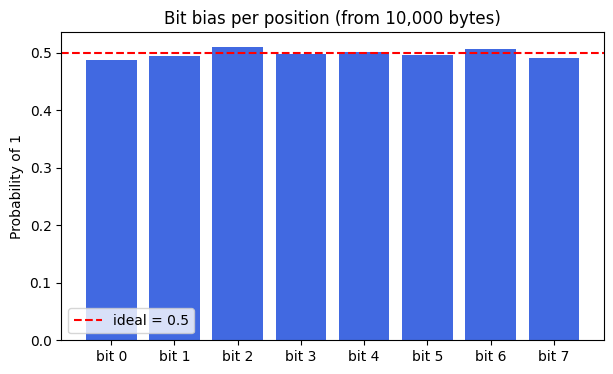


Byte distribution stats:
Min prob: 0.0016, Max prob: 0.0069, Expected = 0.0039


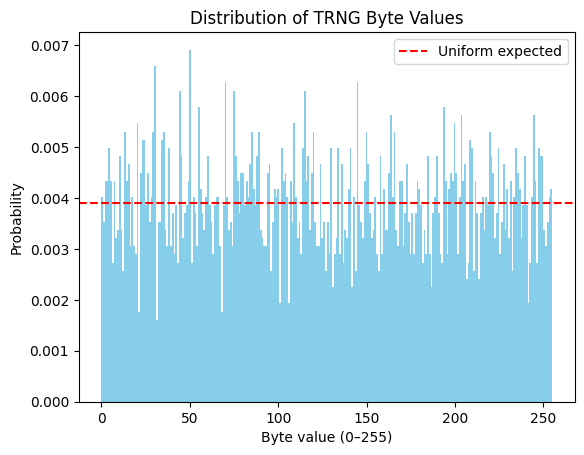

In [ ]:
data = all_samples.flatten()  # load from what we save if needed
# ---------- Analysis ----------
biases = []

for b in range(8):
    ones = np.count_nonzero((data >> b) & 1)
    p1 = ones / len(data)
    biases.append(p1)
    print(f"bit {b}: p1={p1:.5f}")

# ---------- Plot ----------
plt.figure(figsize=(7,4))
plt.bar(range(8), biases, color="royalblue")
plt.axhline(0.5, color="red", linestyle="--", label="ideal = 0.5")
plt.xticks(range(8), [f"bit {i}" for i in range(8)])
plt.ylabel("Probability of 1")
plt.title("Bit bias per position (from 10,000 bytes)")
plt.legend()
plt.show()


# ===== 3. Byte value distribution =====
values, counts = np.unique(data, return_counts=True)
probs = counts / len(data)

print("\nByte distribution stats:")
print(f"Min prob: {probs.min():.4f}, Max prob: {probs.max():.4f}, Expected = {1/256:.4f}")

plt.hist(data, bins=256, range=(0, 255), density=True, color='skyblue')
plt.axhline(1/256, color='r', linestyle='--', label="Uniform expected")
plt.xlabel("Byte value (0–255)")
plt.ylabel("Probability")
plt.title("Distribution of TRNG Byte Values")
plt.legend()
plt.show()


In [6]:
from scipy.stats import entropy

H = entropy(probs, base=2)
print(f"Shannon entropy: {H:.4f} bits per byte (ideal = 8)")


Shannon entropy: 7.9573 bits per byte (ideal = 8)


In [7]:
from scipy.stats import chisquare

# Build observed histogram (256 bins, one per possible byte value)
observed, _ = np.histogram(data, bins=256, range=(0, 256))

# Expected: uniform distribution with same total count
expected = np.full(256, len(data) / 256)

# Chi-square test
chi2, pval = chisquare(observed, expected)
print(f"Chi-square = {chi2:.2f}, p = {pval:.3e}")



Chi-square = 366.68, p = 5.564e-06


In [8]:
# Convert bytes → bits
bits = np.unpackbits(data)

def autocorr(bits, lag):
    return np.corrcoef(bits[:-lag], bits[lag:])[0,1]

for lag in [1, 2, 4, 8, 16]:
    ac = autocorr(bits, lag)
    print(f"Autocorrelation lag {lag}: {ac:.5f}")


Autocorrelation lag 1: -0.00368
Autocorrelation lag 2: -0.00786
Autocorrelation lag 4: -0.00162
Autocorrelation lag 8: 0.00034
Autocorrelation lag 16: -0.00426


In [9]:
import numpy as np
from scipy.stats import chisquare

def poker_test(bits, m_values=[2,3,4,5,6,8]):
    N = len(bits)
    results = []
    for m in m_values:
        num_chunks = N // m
        if num_chunks < 50:
            continue  # not enough samples for this m

        # group into m-bit chunks
        chunks = np.packbits(bits[:num_chunks*m].reshape(-1, m), axis=-1, bitorder='little').flatten()
        freqs = np.bincount(chunks, minlength=2**m)

        # expected counts (uniform)
        expected = np.full(2**m, num_chunks / (2**m))
        chi2, pval = chisquare(freqs, expected)

        results.append((m, chi2, pval))

    return results



bits = np.unpackbits(data)  # turn your bytes into bitstream
results = poker_test(bits)

for m, chi2, pval in results:
    print(f"m={m}: Chi²={chi2:.2f}, p={pval:.3f}")



m=2: Chi²=2.97, p=0.396
m=3: Chi²=6.46, p=0.487
m=4: Chi²=16.21, p=0.368
m=5: Chi²=34.57, p=0.301
m=6: Chi²=76.45, p=0.119
m=8: Chi²=366.68, p=0.000


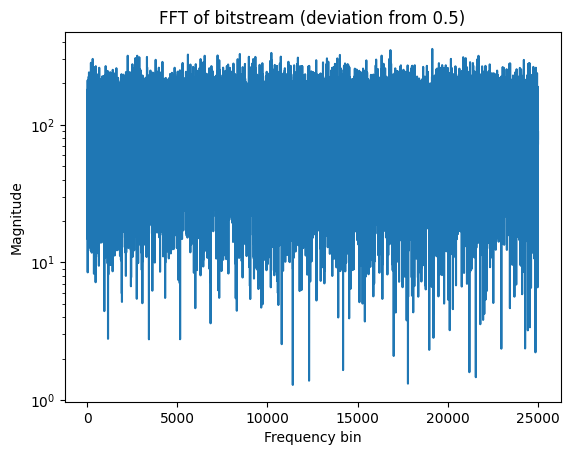

In [10]:
import matplotlib.pyplot as plt

fft_vals = np.fft.fft(bits - 0.5)
plt.semilogy(np.abs(fft_vals[:len(fft_vals)//2]))
plt.title("FFT of bitstream (deviation from 0.5)")
plt.xlabel("Frequency bin")
plt.ylabel("Magnitude")
plt.show()


## 6) Cleanup / disconnect (optional)

In [8]:

try:
    target.dis()
except Exception:
    pass
try:
    scope.dis()
except Exception:
    pass
print("Disconnected.")


Disconnected.
